# 에브리타임 크롤링 데이터 분석

## 데이터 업로드

In [ ]:
!pip install --upgrade konlpy
!pip install soynlp
!pip install git+https://github.com/haven-jeon/PyKoSpacing.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 4.1 MB/s eta 0:00:00
  Cloning https://github.com/haven-jeon/PyKoSpacing.git to /tmp/pip-req-build-jeoroyvv
  Running command git clone --filter=blob:none --quiet https://github.com/haven-jeon/PyKoSpacing.git /tmp/pip-req-build-jeoroyvv
  Resolved https://github.com/haven-jeon/PyKoSpacing.git to commit b32a889cbd10b006d2f4aba118f0cd5b677e2979
  Preparing metadata (setup.py) ... done
  Created wheel for pykospacing: filename=pykospacing-0.5-py3-none-any.whl size=2286920 sha256=25ba82b856d2fff3009c2fabe7d9cced0f006c85a7252fc44374080382a5ae28
  Stored in directory: /tmp/pip-ephem-wheel-cache-v6sgw944/wheels/1f/3f/64/6d5b2c9ba9cd5aa624676868e8ae8ec684672ce1bcbe20add8
Successfully built pykospacing


In [ ]:
# Colab에서 Mecab 실행 위해 필요
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab_light_220429.sh

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 4.55 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2025-05-11 01:46:02--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://bbuseruploads.s3.amazonaws.com/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz?response-content-dispositi

In [ ]:
# Standard library imports
import warnings
import re
import ast
from datetime import datetime, timedelta

# Data manipulation
import numpy as np
import pandas as pd
from google.colab import drive

# Visualization
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from konlpy.tag import Okt, Mecab
from pykospacing import Spacing
from soynlp.normalizer import repeat_normalize, emoticon_normalize

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
fm.findSystemFonts()
!apt-get update -qq
!apt-get install fonts-nanum* -qq
sys_font=fm.findSystemFonts()
nanum_font = [f for f in sys_font if 'Nanum' in f]
nanum_font
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126109 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/공모전/경영경제대학 학술제/everytime_crawling.csv", encoding='cp949')
df.head()

,content,comment,like,comment_count,scrap,date
0,시즌 끝났네… 이걸 또 하라고….?ㅠ,"['졸유함?', '졸유? 졸유는 했지 이미 없었지만', '이번에 한번 더 늘릴거냐'...",11,6,0,05/04 20:39
1,면준 다들 면접준비 얼마나 하시나요,"['프리스타일', '저 중요한곳 할 때는 2주 넘게 햇어요', '면준은 서류 합격 ...",0,7,0,05/04 19:16
2,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나,"['나같은애도 합하더라 포기하지마', '이 말 한 줄에 토익 100점 오른 기분이에...",1,7,0,05/04 18:25
3,cj 인적성 Cj 인적성 단계에서 100% 인적성 점수만 가지고 컷하나요..? 아님...,"['그걸 누가 알까요', 'CJ 할애비도 모름', 'CJ 할애비는 알고 있을 것 같...",0,7,0,05/04 14:39
4,선배님들~! 설문조사 참여 부탁드립니다! 안녕하세요!\n중앙대학교 경영경제대학 학술...,[],4,0,0,05/04 14:25


In [ ]:
df.shape

(7255, 6)

## 데이터 전처리

### 날짜

In [ ]:
def parse_date(s):
    now = datetime.now()
    s = str(s).strip()

    # "n분 전" 패턴
    m = re.match(r'(\d+)\s*분 전', s)
    if m:
        return now - timedelta(minutes=int(m.group(1)))

    # "MM/DD HH:MM" 패턴
    m = re.match(r'(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2})', s)
    if m:
        month, day, hour, minute = map(int, m.groups())
        return datetime(now.year, month, day, hour, minute)

    # 그 외는 변환 불가
    return pd.NaT

In [ ]:
df['parsed_date'] = df['date'].apply(parse_date)
df['parsed_date'].head()

,parsed_date
0,2025-05-04 20:39:00
1,2025-05-04 19:16:00
2,2025-05-04 18:25:00
3,2025-05-04 14:39:00
4,2025-05-04 14:25:00


In [ ]:
df['year']   = df['parsed_date'].dt.year
df['month']  = df['parsed_date'].dt.month
df['day']    = df['parsed_date'].dt.day
df['hour']   = df['parsed_date'].dt.hour
print(df[['parsed_date','year','month','day','hour']].head())

          parsed_date    year  month  day  hour
0 2025-05-04 20:39:00  2025.0    5.0  4.0  20.0
1 2025-05-04 19:16:00  2025.0    5.0  4.0  19.0
2 2025-05-04 18:25:00  2025.0    5.0  4.0  18.0
3 2025-05-04 14:39:00  2025.0    5.0  4.0  14.0
4 2025-05-04 14:25:00  2025.0    5.0  4.0  14.0


In [ ]:
df_tail = df.iloc[2270:].copy()
df_tail.head()

,content,comment,like,comment_count,scrap,date,parsed_date,year,month,day,hour
2270,"재수강 F 질문 재수강한 과목에서 F를 받았는데, 성적증명서에 F로 표기되나요? 아...",['재수강 전 성적으로 기록됨'],0,1,0,2024/12/31 23:45,NaT,NaN,NaN,NaN,NaN
2271,공대 어학점수 없어도 취업 ㄱㄴ??,"['ㅂㄱㄴ 대부분 어학 필수임', '어학점수 만드는데 기간 얼마나 걸릴까요?', '...",0,15,0,2024/12/31 23:02,NaT,NaN,NaN,NaN,NaN
2272,29살에 현금 1억들고 전문직 준비하기 27살에 중견 취직\n뭐가나음?,"['붙는게 확실하면 전자.. 뭐가 나을지는 본인의 역량, 운, 노력에 따라 다르지않...",1,2,0,2024/12/31 22:17,NaT,NaN,NaN,NaN,NaN
2273,초봉 5000 넘으면 아무리 자기랑 적성 안맞고\n전공 살리기 어려운 분야라도\n\...,"['네', '경험해보니 모든 일은 ㅈ같고 그러더라\n무조건 ㄱㄱ']",0,2,0,2024/12/31 21:22,NaT,NaN,NaN,NaN,NaN
2274,전적대 ㅈ문대인 편입생인데 전전이고 취업할 때 불이익 있을까요.. 여기와서 노력해서...,"['편입한거 관심도 없을텐데..', '그런가요?', '입학처는 변리사나 기술고시 1...",1,15,0,2024/12/31 20:38,NaT,NaN,NaN,NaN,NaN


In [ ]:
df_tail['parsed_date'] = pd.to_datetime(df_tail['date'], errors='coerce')
df_tail['year']   = df_tail['parsed_date'].dt.year
df_tail['month']  = df_tail['parsed_date'].dt.month
df_tail['day']    = df_tail['parsed_date'].dt.day
df_tail['hour']   = df_tail['parsed_date'].dt.hour
print(df_tail[['parsed_date','year','month','day','hour']].head())

             parsed_date  year  month  day  hour
2270 2024-12-31 23:45:00  2024     12   31    23
2271 2024-12-31 23:02:00  2024     12   31    23
2272 2024-12-31 22:17:00  2024     12   31    22
2273 2024-12-31 21:22:00  2024     12   31    21
2274 2024-12-31 20:38:00  2024     12   31    20


In [ ]:
df.update(df_tail[['year', 'month', 'day', 'hour']])
print(df[['parsed_date','year','month','day','hour']].tail())

     parsed_date    year  month  day  hour
7250         NaT  2024.0    5.0  4.0  16.0
7251         NaT  2024.0    5.0  4.0  16.0
7252         NaT  2024.0    5.0  4.0  11.0
7253         NaT  2024.0    5.0  4.0  10.0
7254         NaT  2024.0    5.0  4.0  10.0


In [ ]:
df.drop(columns='parsed_date', inplace=True)

### 텍스트

In [ ]:
def clean_comment_str(s):
    # 문자열이면 리스트로 변환 시도
    if isinstance(s, str):
        try:
            lst = ast.literal_eval(s)
        except Exception:
            return []
    else:
        lst = s

    # 리스트인지 확인하고 '삭제된 댓글입니다.'만 제거
    if isinstance(lst, list):
        return [c for c in lst if c.strip() != '삭제된 댓글입니다.']
    else:
        return []

# 컬럼에 적용
df['comment'] = df['comment'].apply(clean_comment_str)

In [ ]:
# PyKoSpacing 인스턴스 생성
spacing = Spacing()

# 정규식 패턴 미리 컴파일
TAG_RE = re.compile(r'<[^>]+>')
URL_RE = re.compile(r'http\S+')
ALPHANUM_RE = re.compile(r'[a-zA-Z0-9]')
SPECIAL_CHAR_RE = re.compile(r'[^\w\s]')
MULTI_SPACE_RE = re.compile(r'\s+')

def clean_text(text: str) -> str:
    """
    입력된 텍스트에서 HTML 태그, URL, 숫자/영어, 특수기호를 제거하고
    다중 공백을 정리한 뒤, PyKoSpacing으로 띄어쓰기를 보정합니다.
    """
    text = TAG_RE.sub(' ', text) # HTML 태그 제거
    text = URL_RE.sub(' ', text) # URL 제거
    text = ALPHANUM_RE.sub(' ', text) # 숫자 및 알파벳 제거
    text = SPECIAL_CHAR_RE.sub(' ', text) # 특수기호 제거
    text = MULTI_SPACE_RE.sub(' ', text).strip() # 다중 공백 정리
    return spacing(text) # 띄어쓰기 보정

# 적용 예시
df['clean_text'] = df['content'].apply(clean_text)

In [ ]:
df['clean_text'].head()

,clean_text
0,시즌 끝났네 이걸 또 하라고 ㅠ
1,면준 다들 면접 준비 얼마나 하시나요
2,최종 합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나
3,인적성 인적성 단계에서 인적성 점수만 가지고 컷 하나요 아님 서류도 다시 볼까요
4,선배님들 설문조사 참여 부탁드립니다 안녕하세요 중앙대학교 경영경제대학 학술제에 참가...


In [ ]:
# 형태소 분석 및 어간 추출 -> Mecab
mecab = Mecab()
df['morphs'] = df['clean_text'].apply(lambda x: mecab.morphs(x))

In [ ]:
df['morphs'].head()

,morphs
0,"[시즌, 끝, 났, 네, 이걸, 또, 하, 라고, ㅠ]"
1,"[면, 준, 다, 들, 면접, 준비, 얼마나, 하, 시, 나요]"
2,"[최종, 합격, 후기, 찾아보, 면, 다, 들, 너무, 반짝, 반짝, 빛난다, 저렇..."
3,"[인적, 성, 인, 적성, 단계, 에서, 인, 적성, 점수, 만, 가지, 고, 컷,..."
4,"[선배, 님, 들, 설문, 조사, 참여, 부탁, 드립니다, 안녕, 하, 세요, 중앙..."


In [ ]:
# 불용어 제거
stopwords = stopwords = {
    # 기본 기능어
    '것', '수', '등', '더', '의',
    # 조사·어미
    '은', '는', '이', '가', '을', '를',
    '에', '에서', '부터', '까지', '으로', '로', '에게',
    # 접속사·전후관계
    '그리고', '하지만', '그러나', '그런데', '그래서',
    # 대명사·지시어
    '나', '우리', '저희', '너', '너희', '이곳', '여기', '저기',
    # 기타 자주 쓰이는 문법어
    '때문', '그러므로', '및',
    # 간단한 감탄사/의성어
    '아', '휴', '아이쿠', '헐', '헉',
    # 추가 사용자 정의 불용어
    '아이구', '아이고', '어', '따라', '의해', '뿐이다', '의거하여', '근거하여', '입각하여', '기준으로',
    '예하면', '예를 들면', '예를 들자면', '저', '소인', '소생', '지말고', '하지마', '하지마라', '다른', '물론',
    '또한', '비길수 없다', '해서는 안된다', '뿐만 아니라', '만이 아니다', '만은 아니다', '막론하고', '관계없이',
    '그치지 않는다', '든간에', '논하지 않는다', '따지지 않는다', '설사', '비록', '더라도', '아니면', '만 못하다',
    '하는 편이 낫다', '불문하고', '향하여', '향해서', '향하다', '쪽으로', '틈타', '이용하여', '타다', '오르다',
    '제외하고', '이 외에', '이 밖에', '하여야', '비로소', '한다면 몰라도', '외에도', '기점으로', '할 생각이다',
    '하려고하다', '이리하여', '그리하여', '그렇게 함으로써', '일때', '할때', '앞에서', '중에서', '보는데서',
    '으로써', '로써', '해야한다', '일것이다', '반드시', '할줄알다', '할수있다', '할수있어', '임에 틀림없다',
    '한다면', '등등', '제', '겨우', '단지', '다만', '할뿐', '딩동', '댕그', '대해서', '대하여', '대하면', '훨씬',
    '얼마나', '얼마만큼', '얼마큼', '남짓', '여', '얼마간', '약간', '다소', '좀', '조금', '다수', '몇', '얼마',
    '지만', '하물며', '이외에도', '대해 말하자면', '다음에', '반대로', '반대로 말하자면', '이와 반대로',
    '바꾸어서 말하면', '바꾸어서 한다면', '만약', '그렇지않으면', '까악', '툭', '딱', '삐걱거리다', '보드득',
    '비걱거리다', '꽈당', '응당', '에 가서', '각', '각각', '여러분', '각종', '각자', '제각기', '하도록하다',
    '와', '과', '고로', '한 까닭에', '하기 때문에', '거니와', '이지만', '관하여', '관한', '과연', '실로',
    '아니나다를가', '생각한대로', '진짜로', '한적이있다', '하곤하였다', '하', '하하', '허허', '아하', '거바',
    '오', '왜', '어째서', '무엇때문에', '어찌', '하겠는가', '무슨', '어디', '어느곳', '더군다나', '더욱이는',
    '어느때', '언제', '야', '이봐', '어이', '여보시오', '흐흐', '흥', '헉헉', '헐떡헐떡', '영차', '여차',
    '어기여차', '끙끙', '아야', '앗', '콸콸', '졸졸', '좍좍', '뚝뚝', '주룩주룩', '솨', '우르르', '그래도',
    '바꾸어말하면', '바꾸어말하자면', '혹은', '혹시', '답다', '때가 되어', '즉', '지든지', '설령', '가령',
    '하더라도', '할지라도', '일지라도', '하마터면', '인젠', '이젠', '된바에야', '된이상', '어찌됏든',
    '그위에', '게다가', '점에서 보아', '비추어 보아', '고려하면', '하게될것이다', '비교적', '보다더', '비하면',
    '시키다', '하게하다', '할만하다', '연이서', '이어서', '잇따라', '뒤따라', '뒤이어', '결국', '의지하여',
    '기대여', '통하여', '자마자', '더욱더', '불구하고', '얼마든지', '마음대로', '주저하지 않고', '곧', '즉시',
    '바로', '당장', '하자마자', '밖에 안된다', '하면된다', '그래', '그렇지', '요컨대', '다시 말하자면',
    '구체적으로', '말하자면', '시작하여', '시초에', '이상', '허', '허걱', '바와같이', '해도좋다', '해도된다',
    '더구나', '와르르', '팍', '퍽', '펄렁', '동안', '이래', '하고있었다', '이었다', '로부터', '같이', '더불어',
    '마저', '양자', '모두', '가까스로', '즈음하여', '해봐요', '습니까', '말할것도 없고', '개의치않고',
    '하는것만 못하다', '하는것이 낫다', '매', '매번', '들', '모', '어느것', '어느', '갖고말하자면', '어느쪽',
    '어느해', '어느 년도', '라 해도', '언젠가', '어떤것', '저쪽', '저것', '그때', '그럼', '그러면', '요만한걸',
    '저것만큼', '그저', '할 줄 안다', '할 힘이 있다', '당신', '설마', '차라리', '놀라다', '상대적으로 말하자면',
    '마치', '아니라면', '쉿', '그렇지 않으면', '안 그러면', '아니었다면', '하든지', '이라면', '좋아', '알았어',
    '그만이다', '어쩔수 없다', '하나', '일', '일반적으로', '일단', '오자마자', '이렇게되면', '이와같다면', '전부',
    '한마디', '한항목', '근거로', '하기에', '아울러', '않기 위해서', '이르기까지', '로 인하여', '까닭으로',
    '이유만으로', '이로 인하여', '이 때문에', '결론을 낼 수 있다', '으로 인하여', '알 수 있다',
    '합니다', '습니다', '된다', '된다면', '되어', '했다', '합니다', '된다면',
    '그냥', '거기', '거의', '같다', '너무', '매우', '많이', '진짜', '완전',
    '인데', '는데', '네요', '어요', '아요', '입니다', '있습니다', '없습니다',
    '나요', '가요', '어요', '아요', '죠', '잖아', '거든요', '네', '군요', '지요',
    '했나요', '가나요', '사나요', '먹나요', '하나요', '되나요', '받나요', '알나요', '있나요', '없나요',
    '되었나요', '오나요', '주나요', '나오나요',
    '말하나요', '알겠나요', '끝났나요', '시작하나요', '가나요', '보나요',
    '하려나요', '괜찮나요', '필요하나요', '필요없나요'
}

**한국어 불용어 리스트** => 절대적인 건 아님<br>
https://www.ranks.nl/stopwords/korean

In [ ]:
df['tokens'] = df['morphs'].apply(lambda tokens: [t for t in tokens if t not in stopwords and len(t) > 1])

In [ ]:
df['tokens'].head()

,tokens
0,"[시즌, 이걸, 라고]"
1,"[면접, 준비]"
2,"[최종, 합격, 후기, 찾아보, 반짝, 반짝, 빛난다, 저렇게, 니깐, 합격, 는구나]"
3,"[인적, 적성, 단계, 적성, 점수, 가지, 아님, 서류, 다시, 볼까요]"
4,"[선배, 설문, 조사, 참여, 부탁, 드립니다, 안녕, 세요, 중앙, 대학교, 경영..."


In [ ]:
# 토큰을 문자열로 결합
df['processed'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

In [ ]:
df['processed'].head()

,processed
0,시즌 이걸 라고
1,면접 준비
2,최종 합격 후기 찾아보 반짝 반짝 빛난다 저렇게 니깐 합격 는구나
3,인적 적성 단계 적성 점수 가지 아님 서류 다시 볼까요
4,선배 설문 조사 참여 부탁 드립니다 안녕 세요 중앙 대학교 경영 경제 대학 학술 참...


#### 감정 분석용 / 토픽 모델링용

In [ ]:
def clean_for_emotion(text):
    # HTML 태그·URL 제거
    text = re.sub(r'<.*?>|http\S+', ' ', text)
    # 숫자 및 알파벳 제거
    text = re.sub(r'[0-9A-Za-z]', ' ', text)
    # 다중 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    # 이모티콘 정규화
    text = emoticon_normalize(text, num_repeats=2)
    # 일반 반복 문자 정규화
    text = repeat_normalize(text, num_repeats=2)
    return text

In [ ]:
# 사용자 정의 복합어 쌍 리스트
COMPOUND_PAIRS = [
    ('자',   '소서'),
    ('자소', '서'),
    ('인적', '성'),
    ('인', '적성')
]

# 명사 태그
NOUN_TAGS = {"NNG", "NNP", "NNB", "NNBC", "NP"}

def merge_compound_morphs(morphs, pairs=COMPOUND_PAIRS, pos="NNG"):
    """
    morphs: [(word, tag), …]
    pairs: [('자','소서'), ('자소','서'), ('인적','성'), …]
    pos: 합쳐진 토큰에 부여할 품사 태그
    """
    merged = []
    i = 0
    while i < len(morphs):
        if i + 1 < len(morphs):
            matched = False
            for a, b in pairs:
                if morphs[i][0] == a and morphs[i+1][0] == b:
                    merged.append((a + b, pos))
                    i += 2
                    matched = True
                    break
            if matched:
                continue
        merged.append(morphs[i])
        i += 1
    return merged

def clean_for_topic(text):
    # HTML·URL 제거
    text = re.sub(r'<.*?>|http\S+', ' ', text)
    # 한글·공백 외 제거
    text = re.sub(r'[^가-힣\s]', ' ', text)
    # 공백 단일화
    text = re.sub(r'\s+', ' ', text).strip()
    # 형태소 분석
    morphs = mecab.pos(text)
    # 복합어 합치기
    morphs = merge_compound_morphs(morphs)
    # 명사만 추출
    tokens = [w for w, t in morphs if t in NOUN_TAGS]
    # 불용어·길이 필터
    tokens = [t for t in tokens if t not in stopwords and len(t) > 1]
    # 문자열로 합쳐서 반환
    return ' '.join(tokens)

In [ ]:
df['comment_text'] = df['comment'].apply(lambda lst: ' '.join(lst) if isinstance(lst, list) else '')
df['emotion_text'] = df['content'].apply(clean_for_emotion)

In [ ]:
df['emotion_text'].head()

,emotion_text
0,시즌 끝났네… 이걸 또 하라고….?ㅠ
1,면준 다들 면접준비 얼마나 하시나요
2,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나
3,인적성 인적성 단계에서 % 인적성 점수만 가지고 컷하나요..? 아님 서류도 다시 볼...
4,선배님들~! 설문조사 참여 부탁드립니다! 안녕하세요! 중앙대학교 경영경제대학 학술제...


In [ ]:
df['topic_text'] = df['clean_text'].apply(clean_for_topic)

In [ ]:
df['topic_text'].head()

,topic_text
0,시즌
1,면접 준비
2,최종 합격 후기 합격
3,인적성 인적성 단계 인적성 점수 서류
4,선배 설문 조사 참여 부탁 중앙 대학교 경영 경제 대학 학술 참가 잡스 중앙 대생 ...


In [ ]:
emotion_df = df[['date', 'year', 'month', 'day', 'hour', 'emotion_text']].copy()
emotion_df

,date,year,month,day,hour,emotion_text
0,05/04 20:39,2025.0,5.0,4.0,20.0,시즌 끝났네… 이걸 또 하라고….?ㅠ
1,05/04 19:16,2025.0,5.0,4.0,19.0,면준 다들 면접준비 얼마나 하시나요
2,05/04 18:25,2025.0,5.0,4.0,18.0,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나
3,05/04 14:39,2025.0,5.0,4.0,14.0,인적성 인적성 단계에서 % 인적성 점수만 가지고 컷하나요..? 아님 서류도 다시 볼...
4,05/04 14:25,2025.0,5.0,4.0,14.0,선배님들~! 설문조사 참여 부탁드립니다! 안녕하세요! 중앙대학교 경영경제대학 학술제...
...,...,...,...,...,...,...
7250,2024/05/04 16:13,2024.0,5.0,4.0,16.0,보통 인식이 증권 >>> 대기업 재무인가요? 학부시절부터 학회랑 인턴 빠르게 테크 ...
7251,2024/05/04 16:01,2024.0,5.0,4.0,16.0,삼성전자 인턴 면스 메모리 공설 파운드리공설 제기담 공기 있습니다. 한분 더 들어오...
7252,2024/05/04 11:22,2024.0,5.0,4.0,11.0,일년정도 공부했는데 재무 경제쪽이 잘맞고 세법쪽은 맞지 않아서 로 다음주부터 진입하...
7253,2024/05/04 10:44,2024.0,5.0,4.0,10.0,전자 말고 & 면스는 없나요ㅜㅠ 인턴인데 같이 준비하고 싶습니다


In [ ]:
topic_df = df[['date', 'year', 'month', 'day', 'hour', 'topic_text']].copy()
topic_df

,date,year,month,day,hour,topic_text
0,05/04 20:39,2025.0,5.0,4.0,20.0,시즌
1,05/04 19:16,2025.0,5.0,4.0,19.0,면접 준비
2,05/04 18:25,2025.0,5.0,4.0,18.0,최종 합격 후기 합격
3,05/04 14:39,2025.0,5.0,4.0,14.0,인적성 인적성 단계 인적성 점수 서류
4,05/04 14:25,2025.0,5.0,4.0,14.0,선배 설문 조사 참여 부탁 중앙 대학교 경영 경제 대학 학술 참가 잡스 중앙 대생 ...
...,...,...,...,...,...,...
7250,2024/05/04 16:13,2024.0,5.0,4.0,16.0,보통 인식 증권 기업 재무 학부 시절 학회 인턴 테크 증권 프론트 사람 공인회계사 ...
7251,2024/05/04 16:01,2024.0,5.0,4.0,16.0,삼성전자 인턴 메모리 공설 파운드리 공설 기담 공기 쪽지 주세요
7252,2024/05/04 11:22,2024.0,5.0,4.0,11.0,정도 공부 재무 경제 세법 다음 진입 학기 병행 시험 응시 시험 응시 고민 추천 가...
7253,2024/05/04 10:44,2024.0,5.0,4.0,10.0,전자 인턴 준비


In [ ]:
%cd /content
emotion_df.to_csv('emotion_df.csv', index=False, encoding='utf-8-sig')
topic_df.to_csv('topic_df.csv', index=False, encoding='utf-8-sig')
df.to_csv('everytime_df.csv', index=False, encoding='utf-8-sig')
print("CSV 파일로 저장 완료")

/content
CSV 파일로 저장 완료


## 토픽 모델링

In [ ]:
!pip install --upgrade --force-reinstall --no-cache-dir gensim pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 144.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 152.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Google Colab 드라이브 마운트
from google.colab import drive

# 데이터 처리
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# 시각화
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# 텍스트 벡터화 & 차원 축소
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

# 진행 표시줄
from tqdm import tqdm

# Gensim 기반 토픽 모델링
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases, Phraser

# 병렬 처리
from joblib import Parallel, delayed

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
topic_df = pd.read_csv("/content/drive/MyDrive/공모전/경영경제대학 학술제/topic_df.csv")
topic_df.head()

,date,year,month,day,hour,topic_text
0,05/04 20:39,2025.0,5.0,4.0,20.0,시즌
1,05/04 19:16,2025.0,5.0,4.0,19.0,면접 준비
2,05/04 18:25,2025.0,5.0,4.0,18.0,최종 합격 후기 합격
3,05/04 14:39,2025.0,5.0,4.0,14.0,인적성 인적성 단계 인적성 점수 서류
4,05/04 14:25,2025.0,5.0,4.0,14.0,선배 설문 조사 참여 부탁 중앙 대학교 경영 경제 대학 학술 참가 잡스 중앙 대생 ...


In [ ]:
def normalize_date(s: str) -> datetime:
    s = s.strip()
    # “YYYY/MM/DD HH:MM” 패턴
    m = re.match(r'(\d{4})/(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2})', s)
    if m:
        year, month, day, hour, minute = map(int, m.groups())
    else:
        # “MM/DD HH:MM” 패턴 (년도가 없으면 2025년으로 간주)
        m = re.match(r'(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2})', s)
        if m:
            month, day, hour, minute = map(int, m.groups())
            year = 2025
        else:
            # 그 외는 NaT 처리
            return pd.NaT
    return datetime(year, month, day, hour, minute)

# 변환 적용
topic_df['date'] = topic_df['date'].apply(normalize_date)

NameError: name 're' is not defined

In [ ]:
# 토큰화된 텍스트 리스트 준비 (topic_df 변수명에 맞춰 수정)
texts = topic_df['topic_text'].dropna().str.split().tolist()

# Dictionary 및 Corpus 생성
dictionary = Dictionary(texts)
corpus     = [dictionary.doc2bow(text) for text in texts]

# 토픽 수 범위 설정
topic_range = list(range(2, 11))

# Coherence 및 Perplexity 점수 저장 리스트
perplexity_scores = []
coherence_scores  = []

# tqdm 진행 막대와 함께 num_topics별로 모델 학습 및 지표 계산
for nt in tqdm(topic_range, desc="Evaluating topics"):
    # LDA 모델 학습
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=nt,
        random_state=42,
        passes=10,
        iterations=100
    )
    # Coherence (c_v)
    coh  = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    # Perplexity (exp2(-log_perplexity))
    logp = model.log_perplexity(corpus)
    perp = np.exp2(-logp)

    coherence_scores.append(coh)
    perplexity_scores.append(perp)

# 결과 시각화: 두 개의 서브플롯으로 분리
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Perplexity
ax1.plot(topic_range, perplexity_scores, 'o-', label='Perplexity')
ax1.set_title('Perplexity by Number of Topics')
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Perplexity')
ax1.grid(True)

# Right: Coherence
ax2.plot(topic_range, coherence_scores, 'o-', color='tab:green', label='Coherence (c_v)')
ax2.set_title('Coherence by Number of Topics')
ax2.set_xlabel('Number of Topics')
ax2.set_ylabel('Coherence Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

Evaluating topics:   0%|          | 0/13 [00:23<?, ?it/s]


NameError: name 'np' is not defined

**Perplexity(불확실성)**/**Coherence(의미적 일관성)**

In [ ]:
# 불용어 제거
stopwords = stopwords = {
    # 기본 기능어
    '것', '수', '등', '더', '의',
    # 조사·어미
    '은', '는', '이', '가', '을', '를',
    '에', '에서', '부터', '까지', '으로', '로', '에게',
    # 접속사·전후관계
    '그리고', '하지만', '그러나', '그런데', '그래서',
    # 대명사·지시어
    '나', '우리', '저희', '너', '너희', '이곳', '여기', '저기',
    # 기타 자주 쓰이는 문법어
    '때문', '그러므로', '및',
    # 간단한 감탄사/의성어
    '아', '휴', '아이쿠', '헐', '헉',
    # 추가 사용자 정의 불용어
    '아이구', '아이고', '어', '따라', '의해', '뿐이다', '의거하여', '근거하여', '입각하여', '기준으로',
    '예하면', '예를 들면', '예를 들자면', '저', '소인', '소생', '지말고', '하지마', '하지마라', '다른', '물론',
    '또한', '비길수 없다', '해서는 안된다', '뿐만 아니라', '만이 아니다', '만은 아니다', '막론하고', '관계없이',
    '그치지 않는다', '든간에', '논하지 않는다', '따지지 않는다', '설사', '비록', '더라도', '아니면', '만 못하다',
    '하는 편이 낫다', '불문하고', '향하여', '향해서', '향하다', '쪽으로', '틈타', '이용하여', '타다', '오르다',
    '제외하고', '이 외에', '이 밖에', '하여야', '비로소', '한다면 몰라도', '외에도', '기점으로', '할 생각이다',
    '하려고하다', '이리하여', '그리하여', '그렇게 함으로써', '일때', '할때', '앞에서', '중에서', '보는데서',
    '으로써', '로써', '해야한다', '일것이다', '반드시', '할줄알다', '할수있다', '할수있어', '임에 틀림없다',
    '한다면', '등등', '제', '겨우', '단지', '다만', '할뿐', '딩동', '댕그', '대해서', '대하여', '대하면', '훨씬',
    '얼마나', '얼마만큼', '얼마큼', '남짓', '여', '얼마간', '약간', '다소', '좀', '조금', '다수', '몇', '얼마',
    '지만', '하물며', '이외에도', '대해 말하자면', '다음에', '반대로', '반대로 말하자면', '이와 반대로',
    '바꾸어서 말하면', '바꾸어서 한다면', '만약', '그렇지않으면', '까악', '툭', '딱', '삐걱거리다', '보드득',
    '비걱거리다', '꽈당', '응당', '에 가서', '각', '각각', '여러분', '각종', '각자', '제각기', '하도록하다',
    '와', '과', '고로', '한 까닭에', '하기 때문에', '거니와', '이지만', '관하여', '관한', '과연', '실로',
    '아니나다를가', '생각한대로', '진짜로', '한적이있다', '하곤하였다', '하', '하하', '허허', '아하', '거바',
    '오', '왜', '어째서', '무엇때문에', '어찌', '하겠는가', '무슨', '어디', '어느곳', '더군다나', '더욱이는',
    '어느때', '언제', '야', '이봐', '어이', '여보시오', '흐흐', '흥', '헉헉', '헐떡헐떡', '영차', '여차',
    '어기여차', '끙끙', '아야', '앗', '콸콸', '졸졸', '좍좍', '뚝뚝', '주룩주룩', '솨', '우르르', '그래도',
    '바꾸어말하면', '바꾸어말하자면', '혹은', '혹시', '답다', '때가 되어', '즉', '지든지', '설령', '가령',
    '하더라도', '할지라도', '일지라도', '하마터면', '인젠', '이젠', '된바에야', '된이상', '어찌됏든',
    '그위에', '게다가', '점에서 보아', '비추어 보아', '고려하면', '하게될것이다', '비교적', '보다더', '비하면',
    '시키다', '하게하다', '할만하다', '연이서', '이어서', '잇따라', '뒤따라', '뒤이어', '결국', '의지하여',
    '기대여', '통하여', '자마자', '더욱더', '불구하고', '얼마든지', '마음대로', '주저하지 않고', '곧', '즉시',
    '바로', '당장', '하자마자', '밖에 안된다', '하면된다', '그래', '그렇지', '요컨대', '다시 말하자면',
    '구체적으로', '말하자면', '시작하여', '시초에', '이상', '허', '허걱', '바와같이', '해도좋다', '해도된다',
    '더구나', '와르르', '팍', '퍽', '펄렁', '동안', '이래', '하고있었다', '이었다', '로부터', '같이', '더불어',
    '마저', '양자', '모두', '가까스로', '즈음하여', '해봐요', '습니까', '말할것도 없고', '개의치않고',
    '하는것만 못하다', '하는것이 낫다', '매', '매번', '들', '모', '어느것', '어느', '갖고말하자면', '어느쪽',
    '어느해', '어느 년도', '라 해도', '언젠가', '어떤것', '저쪽', '저것', '그때', '그럼', '그러면', '요만한걸',
    '저것만큼', '그저', '할 줄 안다', '할 힘이 있다', '당신', '설마', '차라리', '놀라다', '상대적으로 말하자면',
    '마치', '아니라면', '쉿', '그렇지 않으면', '안 그러면', '아니었다면', '하든지', '이라면', '좋아', '알았어',
    '그만이다', '어쩔수 없다', '하나', '일', '일반적으로', '일단', '오자마자', '이렇게되면', '이와같다면', '전부',
    '한마디', '한항목', '근거로', '하기에', '아울러', '않기 위해서', '이르기까지', '로 인하여', '까닭으로',
    '이유만으로', '이로 인하여', '이 때문에', '결론을 낼 수 있다', '으로 인하여', '알 수 있다',
    '합니다', '습니다', '된다', '된다면', '되어', '했다', '합니다', '된다면',
    '그냥', '거기', '거의', '같다', '너무', '매우', '많이', '진짜', '완전',
    '인데', '는데', '네요', '어요', '아요', '입니다', '있습니다', '없습니다',
    '나요', '가요', '어요', '아요', '죠', '잖아', '거든요', '네', '군요', '지요',
    '했나요', '가나요', '사나요', '먹나요', '하나요', '되나요', '받나요', '알나요', '있나요', '없나요',
    '되었나요', '오나요', '주나요', '나오나요',
    '말하나요', '알겠나요', '끝났나요', '시작하나요', '가나요', '보나요',
    '하려나요', '괜찮나요', '필요하나요', '필요없나요'
}

In [ ]:
# 빈 텍스트 제거
topic_df = topic_df.dropna(subset=['topic_text'])
topic_df = topic_df[topic_df['topic_text'].str.strip().astype(bool)]

# CountVectorizer: BoW 벡터화
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=list(stopwords))
X = vectorizer.fit_transform(topic_df['topic_text'])

# LDA 학습 (토픽 수는 필요에 따라 조정)
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

# 토픽별 주요 키워드 출력
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
  top_words = [words[j] for j in topic.argsort()[:-7:-1]]
  print(f"토픽 {i}: {' '.join(top_words)}")

# 각 문서의 dominant topic 할당
topic_df['dominant_topic'] = lda.transform(X).argmax(axis=1)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['가서', '결론을', '그렇게', '그치지', '까닭에', '낫다', '년도', '논하지', '다시', '대해', '들면', '들자면', '따지지', '때가', '때문에', '만은', '만이', '말하면', '말할것도', '몰라도', '못하다', '바꾸어서', '밖에', '보아', '비길수', '비추어', '뿐만', '상대적으로', '생각이다', '아니다', '아니라', '안다', '안된다', '않고', '않기', '않는다', '않으면', '어쩔수', '없고', '없다', '예를', '외에', '위해서', '이로', '이와', '인하여', '임에', '있다', '점에서', '주저하지', '틀림없다', '편이', '하기', '하는', '하는것만', '하는것이', '함으로써', '해도', '해서는', '힘이'] not in stop_words.
  warnings.warn(


토픽 0: 채용 취업 기업 가능 개발 서울
토픽 1: 면접 사람 서류 기업 인적성 스터디
토픽 2: 인턴 직무 준비 지원 경험 취업


In [ ]:
# 데이터와 토큰화
texts = topic_df['topic_text'].dropna().str.split().tolist()

# Dictionary·Corpus 생성
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# num_topics=5 로 LDA 학습
model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=10,
    iterations=100
)

# pyLDAvis 대화형 시각화 준비
pyLDAvis.enable_notebook()
lda_vis = gensimvis.prepare(
    topic_model=model,
    corpus=corpus,
    dictionary=dictionary,
    sort_topics=False
)

# 인터랙티브 시각화 표시
lda_vis

# HTML 파일로 저장
%cd /content
pyLDAvis.save_html(lda_vis, 'lda_visualization.html')

/content


**버블 위치/거리** → 토픽 간 유사도

**버블 크기** → 말뭉치에서 그 토픽의 상대적 비중

**우측 바 차트** → 선택된 토픽에서 가장 자주 / 두드러지게 등장하는 단어

**λ 슬라이더** → “빈도(frequency) 중심” vs “토픽 특이성(exclusivity) 중심”
- 0 근처 → 타 토픽과 겹치지 않는 ‘풍부한’ 고유 단어
- 1 근처 → 문서 양이 많은 공통 단어

In [ ]:
#토픽별 문서 수
plt.figure(figsize=(8, 5))
sns.countplot(data=topic_df, x='dominant_topic', palette='Set2')
plt.title('토픽별 문서 수')
plt.xlabel('토픽')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()

#시간대별 토픽 빈도
hour_topic = topic_df.pivot_table(index='hour', columns='dominant_topic', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(hour_topic, cmap='YlGnBu', annot=True, fmt='d')
plt.title('시간대별 토픽 등장')
plt.xlabel('토픽')
plt.ylabel('시간대')
plt.tight_layout()
plt.show()

#요일별 토픽 빈도
topic_df['weekday'] = pd.to_datetime(topic_df['date']).dt.dayofweek
weekday_labels = ['월', '화', '수', '목', '금', '토', '일']
topic_df['weekday'] = topic_df['weekday'].map(dict(zip(range(7), weekday_labels)))
weekday_topic = topic_df.pivot_table(index='weekday', columns='dominant_topic', aggfunc='size', fill_value=0)
weekday_topic = weekday_topic.reindex(['월', '화', '수', '목', '금', '토', '일'])  # 순서 정렬
plt.figure(figsize=(10, 5))
sns.heatmap(weekday_topic, annot=True, fmt='d', cmap='YlOrRd')
plt.title('요일별 토픽 분포')
plt.xlabel('토픽')
plt.ylabel('요일')
plt.tight_layout()
plt.show()

#월별 토픽 변화
monthly_topic = topic_df.groupby(['month', 'dominant_topic']).size().unstack(fill_value=0)
monthly_topic.plot(marker='o', figsize=(10, 5))
plt.title('월별 토픽별 문서 수')
plt.xlabel('월')
plt.ylabel('문서 수')
plt.grid(True)
plt.tight_layout()
plt.show()

#토픽별 글 길이 분포
topic_df['text_length'] = topic_df['topic_text'].apply(len)
plt.figure(figsize=(8, 5))
sns.boxplot(data=topic_df, x='dominant_topic', y='text_length', palette='Set3')
plt.title('토픽별 글 길이')
plt.xlabel('토픽')
plt.ylabel('글 길이 (문자 수)')
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x500 with 0 Axes>

## EDA

### 토픽 별 키워드 워드 클라우드

In [ ]:
from wordcloud import WordCloud

In [ ]:
okt = Okt()

def extract_nouns(texts):
    nouns = []
    for text in texts:
        if isinstance(text, str):
            nouns += okt.nouns(text)
    return [n for n in nouns if len(n) > 1]  # 한 글자 제외

In [ ]:
from collections import Counter

# 토픽 개수 파악 (예: 0~4)
num_topics = topic_df['dominant_topic'].nunique()

for topic_num in range(num_topics):
    # 해당 토픽 글 모으기
    topic_texts = topic_df[topic_df['dominant_topic'] == topic_num]['topic_text']

    # 명사만 추출
    nouns = extract_nouns(topic_texts)

    # 빈도수 계산
    noun_freq = Counter(nouns)

    # 워드클라우드 생성
    wc = WordCloud(
        font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',  # 한글 폰트
        background_color='white',
        width=800,
        height=400
    ).generate_from_frequencies(noun_freq)

    # 시각화
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_num} 워드클라우드')
    plt.show()


### 댓글 수와 추천 수의 상관관계

## 가설 설정 및 검정

### 가설 1. 요일별로 토픽 분포가 다르다

In [ ]:
from scipy.stats import chi2_contingency

# 교차표 생성
contingency_table = pd.crosstab(topic_df['weekday'], topic_df['dominant_topic'])

print("요일별 토픽 분포:")
print(contingency_table)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n[카이제곱 독립성 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대빈도]")
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df)

# 시각화 (heatmap)
plt.figure(figsize=(10, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('요일별 토픽 분포 (Observed)')
plt.xlabel('토픽')
plt.ylabel('요일')
plt.tight_layout()
plt.show()


- p > 0.05
- 요일에 따라 토픽 분포는 다르지 않다

### 가설 2. 월별로 토픽 분포가 다르다

In [ ]:
# 월별-토픽 교차표 생성
monthly_topic_ct = pd.crosstab(topic_df['month'], topic_df['dominant_topic'])

print("월별 토픽 분포:")
print(monthly_topic_ct)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(monthly_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
expected_df = pd.DataFrame(expected, index=monthly_topic_ct.index, columns=monthly_topic_ct.columns)
print(expected_df)

# 시각화
plt.figure(figsize=(10, 5))
sns.heatmap(monthly_topic_ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('월별 토픽 분포 Heatmap')
plt.xlabel('토픽 번호')
plt.ylabel('월')
plt.tight_layout()
plt.show()


- p < 0.05
- 월에 따라 토픽 분포는 통계적으로 유의미하게 다르다

In [ ]:
!pip install wordcloud
!apt-get -qq install fonts-nanum

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 나눔고딕 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
plt.rc('font', family='NanumGothic')

In [ ]:
# 명사 추출 함수 생성
from konlpy.tag import Okt
okt = Okt()

def extract_nouns(text):
    return [noun for noun in okt.nouns(text) if len(noun) > 1]

In [ ]:
from wordcloud import WordCloud

top_topic_by_month = topic_df.groupby('month')['dominant_topic'].agg(lambda x: x.value_counts().idxmax())

for month, top_topic in top_topic_by_month.items():
    # 해당 월 & 최빈 토픽 필터링
    filtered_texts = topic_df[(topic_df['month'] == month) & (topic_df['dominant_topic'] == top_topic)]['topic_text']

    # 명사 추출
    noun_list = []
    for text in filtered_texts:
        noun_list.extend(extract_nouns(text))

    # 리스트를 문자열로 결합
    combined_nouns = ' '.join(noun_list)

    custom_stopwords = set([
    '것', '수', '등', '더', '의', '이런', '저런', '그런', '이렇게', '저렇게', '같이', '근데',
    '그래서', '그러면', '그런데', '하면', '해서', '되다', '하다', '되는데', '했는데', '하니까',
    '던데', '하더라', '같다', '보니까', '생각', '느낌', '정도', '약간', '진짜', '너무',
    '조금', '그냥', '걸', '때', '좀', '안', '거', '건', '게', '냐', '죠', '음', '아', '어'
])


    # 워드클라우드 생성
    wordcloud = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=400,
        stopwords=custom_stopwords
    ).generate(combined_nouns)

    # 시각화
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{month}월 | 최빈 토픽 {top_topic} 명사 기반 워드클라우드')
    plt.tight_layout()
    plt.show()


명사만 추출해서 월별 최빈 토픽으로 워드클라우드 만들어보앗어요 일단.........

### 가설 3. 시간대별로 토픽 분포가 다르다

In [ ]:
# 시간대 구간 나누기
bins = [0, 6, 12, 18, 24]
labels = ['야간', '오전', '오후', '저녁']
topic_df['time_bin'] = pd.cut(topic_df['hour'], bins=bins, labels=labels, right=False)

# 시간대별 토픽 분포 교차표 만들기
time_topic_ct = pd.crosstab(topic_df['time_bin'], topic_df['dominant_topic'])
print("📊 [교차표] 시간대별 토픽 분포:")
print(time_topic_ct)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(time_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
print(pd.DataFrame(expected, index=time_topic_ct.index, columns=time_topic_ct.columns))

# 시각화
plt.figure(figsize=(10, 5))
sns.heatmap(time_topic_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('시간대별 토픽 분포 Heatmap')
plt.xlabel('토픽 번호')
plt.ylabel('시간대')
plt.tight_layout()
plt.show()

- p < 0.05
- 시간대에 따라 토픽 분포에는 유의미한 차이가 있다
(시간대는 일단 임의로 나눔)

### 가설 4. 토픽 별 문서 수에 차이가 있다

In [ ]:
from scipy.stats import chisquare

# 토픽별 문서 수 카운트
topic_counts = topic_df['dominant_topic'].value_counts().sort_index()
observed = topic_counts.values

# 기대값: 모든 토픽이 균등하게 분포한다고 가정
expected = [len(topic_df) / len(topic_counts)] * len(topic_counts)

# 카이제곱 적합도 검정
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# 결과 출력
print("[카이제곱 적합도 검정 결과]")
print(f"Chi-squared 통계량: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 시각화
plt.figure(figsize=(7, 4))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='pastel')
plt.title('토픽별 문서 수 분포')
plt.xlabel('dominant_topic')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()


- p < 0.05
- 토픽별 문서 수에는 유의미한 차이가 있다

### 가설 5. 토픽 별 글 길이에는 차이가 있다

In [ ]:
# topic_text의 글자 수 기준 글 길이 컬럼 추가
topic_df['text_length'] = topic_df['topic_text'].str.len()

2. 등분산성 검정부터...
(평균 비교라 정규화는 따로 안햇더요)

In [ ]:
from scipy.stats import levene, shapiro

# 등분산 검정 (Levene's test)
levene(*[group['text_length'] for _, group in topic_df.groupby('dominant_topic')])

In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg

# Welch's ANOVA
welch_result = pg.welch_anova(dv='text_length', between='dominant_topic', data=topic_df)

print("Welch ANOVA 결과")
print(welch_result)

- p-unc < 0.05
- np2 = 0.066 -> 약간 낮은 중간 효과
- 토픽에 따른 글 길이에는 유의미한 차이가 있다

In [ ]:
pg.pairwise_gameshowell(dv='text_length', between='dominant_topic', data=topic_df)

- 유의미한 차이 없는 쌍: 0-4, 2-3
- 토픽 2, 3이 다른 토픽에 비해 유의미하게 글이 길고 토픽 0, 4는 다른 토픽에 비해 유의미하게 글이 짧다

### 가설 6. 추천수에 따라 토픽의 차이가 있다.

In [ ]:
from scipy.stats import chi2_contingency

# 1. 추천 수 기준 이진 변수 생성 (예: 평균 이상 vs 미만)
threshold = df['like'].mean()
topic_df['like_level'] = df['like'] >= threshold

# 2. 교차표 생성 (추천수 수준 vs 토픽)
like_topic_ct = pd.crosstab(topic_df['like_level'], topic_df['dominant_topic'])

print("추천수 수준에 따른 토픽 분포:")
print(like_topic_ct)

# 3. 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(like_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
expected_df = pd.DataFrame(expected, index=like_topic_ct.index, columns=like_topic_ct.columns)
print(expected_df)

# 4. 시각화
plt.figure(figsize=(8, 4))
sns.heatmap(like_topic_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('추천수 수준에 따른 토픽 분포 (Observed)')
plt.xlabel('토픽 번호')
plt.ylabel('추천수 수준 (True=높음)')
plt.tight_layout()
plt.show()


- p-value: 0.0647
(신뢰수준 95% 하에서는 귀무가설을 기각할 수 없지만 인간행동 분석임을 고려해서 신뢰수준 90%하에서 해석을 진행해보자면,,,)

토픽 3이 다른 토픽에 비해 기대빈도와 관측빈도의 차이가 큼
-> 개발 계열 채용, IT 직무 준비 흐름 등의 내용이 다른 이용자에게 정보성 글 역할을 하였을 것


## 감정 모델링

### 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data/everytime_with_emotion_final_utf8sig.csv', encoding='utf-8-sig')
df.head()

In [ ]:
# 1. 라이브러리 설치 (처음 1번만 실행)
!pip install -U sentence-transformers

In [ ]:
# 2. 불러오기
from sentence_transformers import SentenceTransformer
import pandas as pd

# 3. 모델 불러오기
model = SentenceTransformer('jhgan/ko-sbert-nli')  # 한국어에 특화된 SBERT

# 5. 결측치 제거 (예외 방지)
df = df[df['emotion_text'].notnull()].reset_index(drop=True)

# 6. 임베딩 벡터 추출
df['embedding'] = df['emotion_text'].apply(lambda x: model.encode(x))

# 확인
print(df[['emotion_text', 'embedding']].head(3))

- 감정 분석은 텍스트에 등장하는 단어들을 통해 어떤 감정이 드러나는지 분석하는 기법
- 미리 정의된 감정 어휘 사전이 필요
- 감정 어휘 사전에 포함된 어휘가 텍스트에 얼마나 분포하는지에 따라 해당 텍스트의 감정이 좌우
- 토픽 모델링이 텍스트의 주제를 찾아낸다면, 감정 분석은 텍스트의 의견을 찾아냄
- 즉, 텍스트는 주제(토픽)와 의견(감정)의 결합으로 이뤄졌다고 볼 수 있음


- 파이썬으로 감정 분석하는 방법
  - 감정 어휘 사전을 이용한 감정 상태 분류
    - 미리 분류해둔 감정어 사전을 통해 분석하고자 하는 텍스트의 단어들을 사전에 기반해 분류하고, 그 감정가를 계산
    - 이 때 사용되는 감정어 사전에는 해당 감정에 해당되는 단어를 미리 정의해둬야 함
  - 기계학습을 이용한 감정 상태 분류
    - 분석 데이터의 일부를 훈련 데이터로 사용해 그로부터 텍스트의 감정 상태를 분류

### 감정 사전 준비

- 감정 사전 라이브러리 설치
- afinn은 영어에 대한 긍정, 부정에 대한 감정 사전을 제공

### 기계학습을 이용한 감정 분석

#### 한국어 자연어 처리 konlpy와 형태소 분석기 MeCab 설치
- 형태소 분석기 https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh

In [ ]:
!set -x \
&& pip install konlpy \
&& curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh

In [ ]:
!curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

In [ ]:
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from konlpy.tag import Mecab
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 감정 분석 모델 비교

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import torch, numpy as np

# # KoELECTRA NSMC 파인튜닝 모델 불러오기
# model_name = "monologg/koelectra-small-finetuned-nsmc"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name)

# # 예시 문장 입력
# text = "이 영화는 정말 재미있어요!"
# inputs = tokenizer(text, return_tensors="pt")
# outputs = model(**inputs)

# # Softmax로 확률 계산
# logits = outputs.logits               # 모델 출력 로짓 값
# probs = torch.nn.functional.softmax(logits, dim=1)[0]  # 소프트맥스 확률
# probs = probs.detach().numpy()        # numpy 배열로 변환

# # 예측 레이블 결정
# pred_label_idx = np.argmax(probs)     # 가장 높은 확률의 인덱스
# # 모델 config에 id2label 이 정의돼 있다면 사용, 없으면 직접 매핑
# label_map = model.config.id2label if model.config.id2label else {0: "NEG", 1: "POS"}
# pred_label = label_map[pred_label_idx]

# print(f"각 클래스 확률: {probs}")       # 예: [0.002, 0.998] 형태
# print(f"예측 감정: {pred_label}")      # 예: "POSITIVE" (긍정)

In [ ]:
# model_name = "alsgyu/sentiment-analysis-fine-tuned-model"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name)

# text = "영화 내용이 평범했고 그럭저럭 볼 만했습니다."
# inputs = tokenizer(text, return_tensors="pt")
# outputs = model(**inputs)

# probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0].tolist()  # 파이썬 리스트로 변환
# pred_idx = probs.index(max(probs))  # 최고 확률 인덱스

# # id2label이 정의되었다면 사용, 아니면 수동으로 매핑 가정
# label_map = model.config.id2label if model.config.id2label else {0: "부정", 1: "중립", 2: "긍정"}
# pred_label = label_map[pred_idx]

# print(f"확률 분포: {probs}")      # 예: [0.1, 0.7, 0.2] (부정, 중립, 긍정 확률)
# print(f"예측 감정: {pred_label}")  # 예: "중립"

In [ ]:
# from transformers import pipeline

# model_name = "tabularisai/multilingual-sentiment-analysis"
# clf = pipeline("text-classification", model=model_name, tokenizer=model_name)

# text = "이 제품은 가격 대비 품질이 훌륭하네요!"
# results = clf(text, return_all_scores=True)

# # 결과 출력
# for res in results[0]:
#     label = res['label']
#     score = res['score']
#     print(f"{label}: {score:.4f}")
# # 예시 출력 형태:
# # Very Negative: 0.0001
# # Negative: 0.0010
# # Neutral: 0.05
# # Positive: 0.20
# # Very Positive: 0.7489

# # 최종 예측 레이블 (스코어 최고값의 레이블)
# pred_label = max(results[0], key=lambda x: x['score'])['label']
# print("예측 감정:", pred_label)

In [ ]:
pip install transformers

In [ ]:
import pandas as pd
from transformers import pipeline


# 감정 분석 파이프라인 설정
model_name = "tabularisai/multilingual-sentiment-analysis"
classifier = pipeline("text-classification", model=model_name, tokenizer=model_name)

# 다국어 5단계 결과 → 3단계로 변환하는 함수
def map_sentiment_5_to_3(text):
    try:
        result = classifier(text, return_all_scores=True)[0]
        scores = {item['label']: item['score'] for item in result}
        # 가장 높은 점수 기준
        top_label = max(scores, key=scores.get)

        if top_label in ["Very Negative", "Negative"]:
            return "negative"
        elif top_label in ["Very Positive", "Positive"]:
            return "positive"
        else:
            return "neutral"
    except:
        return "neutral"  # 에러 발생 시 기본값

# 감정 분석 적용
df['emotion'] = df['emotion_text'].astype(str).apply(map_sentiment_5_to_3)

# 결과 확인
print(df[['emotion_text', 'emotion']].head())

# 저장
df.to_csv("everytime_with_emotion.csv", index=False)

In [ ]:
df = pd.read_csv("everytime_with_emotion.csv")
df.to_csv("everytime_with_emotion_utf8sig.csv", index=False, encoding='utf-8-sig')

In [ ]:
!pip install transformers pandas tqdm

import pandas as pd
from transformers import pipeline
from tqdm import tqdm
import time

# ✅ 1. 데이터 불러오기
df = df.dropna(subset=['emotion_text']).reset_index(drop=True)

# ✅ 2. 사용할 모델 정의 및 파이프라인 생성
models = {
    "multilingual": "tabularisai/multilingual-sentiment-analysis",
    "koelectra": "monologg/koelectra-small-finetuned-nsmc"
}

pipelines = {
    k: pipeline("text-classification", model=v, tokenizer=v)
    for k, v in models.items()
}

# ✅ 3. 매핑 함수 정의
def map_multilingual(output):
    label = output[0]['label']
    if label in ["Very Negative", "Negative"]:
        return "negative"
    elif label in ["Very Positive", "Positive"]:
        return "positive"
    else:
        return "neutral"

def map_koelectra(output):
    label = output[0]['label'].lower()
    return "positive" if label == "positive" else "negative"  # koelectra는 중립 없음

# ✅ 4. 감정 분석 수행
results = {k: [] for k in models}
for text in tqdm(df['emotion_text'].astype(str), desc="감정 분석 중"):
    for k in models:
        try:
            output = pipelines[k](text, truncation=True)
            if k == "multilingual":
                results[k].append(map_multilingual(output))
            else:
                results[k].append(map_koelectra(output))
        except:
            results[k].append("error")
    time.sleep(0.02)  # 너무 빠르게 돌리지 않기

# ✅ 5. 결과 반영
for k in models:
    df[f"pred_{k}"] = results[k]

# ✅ 6. 최종 결정 (일치 시 확정, 불일치 시 manual)
def decide_final(row):
    preds = [row[f"pred_{k}"] for k in models]
    return preds[0] if all(p == preds[0] for p in preds) else "manual"

df['final_emotion'] = df.apply(decide_final, axis=1)

# ✅ 7. 저장
df.to_csv("everytime_with_emotion_final.csv", index=False)
manual_df = df[df['final_emotion'] == "manual"]
manual_df.to_csv("manual_review_needed.csv", index=False)

print("✅ 감정 분석 완료! 결과 저장됨:")
print("- 전체 결과: everytime_with_emotion_final.csv")
print("- 수작업 필요한 문장: manual_review_needed.csv")

In [ ]:
df = pd.read_csv("everytime_with_emotion_final.csv")
df.to_csv("everytime_with_emotion_final_utf8sig.csv", index=False, encoding='utf-8-sig')

### TF-IDF

In [ ]:
# # ✅ 1. Hugging Face 라이브러리 설치
# !pip install transformers datasets accelerate -q
# !pip install sentencepiece -q

In [ ]:
# !pip install -q transformers datasets accelerate sentencepiece

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# # import os
# # os.environ["OPENBLAS_NUM_THREADS"] = "1"

# # import pandas as pd
# # from sklearn.feature_extraction.text import TfidfVectorizer
# # from sklearn.linear_model import LogisticRegression
# # from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report

# # 데이터 불러오기
# df = pd.read_csv('/content/drive/MyDrive/data/everytime_with_emotion_final_utf8sig.csv')

# # 레이블 필터링
# df = df[df['emotion'].isin(['positive', 'neutral', 'negative'])].copy()
# df.dropna(subset=['emotion_text'], inplace=True)

# # 샘플링
# df_sampled = df.sample(n=500, random_state=42)

# # 벡터화
# vectorizer = TfidfVectorizer(max_features=3000)
# X = vectorizer.fit_transform(df_sampled['emotion_text'])

# # 레이블 인코딩
# label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
# y = df_sampled['emotion'].map(label_map)

# # 학습-테스트 분할
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 모델 학습
# model = LogisticRegression(max_iter=500)
# model.fit(X_train, y_train)

# # 평가
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred, target_names=label_map.keys()))

지금처럼 감정 nuance가 필요한 문장은 context 이해가 중요

단어만 보고 판단하는 TF-IDF는 한계가 있음

➤ KoBERT, KcELECTRA 같은 BERT 계열로 바꾸면 성능 급상승 가능

### KoBERT

In [ ]:
!pip install transformers datasets accelerate sentencepiece -q

In [ ]:
import transformers
print(transformers.__version__)  # 4.51.3 확인
from transformers import TrainingArguments, Trainer

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# 데이터셋 전처리
import pandas as pd
from datasets import Dataset

# 감정 레이블 필터링
df = df[df['final_emotion'].isin(["positive", "neutral", "negative"])].copy()
df.dropna(subset=["emotion_text"], inplace=True)

# 레이블 숫자로 변환
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["final_emotion"].map(label_map)

# HuggingFace Dataset으로 변환
dataset = Dataset.from_pandas(df[["emotion_text", "label"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)

rev_label_map = {v: k for k, v in label_map.items()}

In [ ]:
# KoBERT 모델 로딩 및 토큰화
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("monologg/kobert")

def tokenize(batch):
    return tokenizer(batch["emotion_text"], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize, batched=True)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True
)

In [ ]:
training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    do_eval=True,
    do_train=True
)

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained("monologg/kobert", num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

### KoBERT-like 모델
- KoBERT 구조가 복잡해서 Trainer로 잘 안 돌아가서
아예 HuggingFace에서 Trainer 완전 호환되는 KoBERT-like 모델로 전환..

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")
model = AutoModelForSequenceClassification.from_pretrained("skt/kobert-base-v1", num_labels=3)

In [ ]:
!pip install --upgrade transformers

In [ ]:
!pip install datasets
!pip install scikit-learn
!pip install accelerate

In [ ]:
import pandas as pd

# 업로드한 CSV 파일 경로에 맞춰 수정
# df = pd.read_csv('/content/everytime_with_emotion_final_utf8sig.csv', encoding='utf-8-sig')
df = df[['emotion_text', 'emotion']]  # 필요한 열만 사용
df = df.dropna()

# 레이블 인코딩
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['emotion'].map(label_map)

# 훈련/검증 데이터 나누기
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['emotion_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")

# 토큰화
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# HuggingFace Dataset 객체로 변환
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
# df = pd.read_csv("/content/everytime_with_emotion_final_utf8sig.csv", encoding="utf-8-sig")
df = df[['emotion_text', 'emotion']].dropna()

label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["emotion"].map(label_map)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["emotion_text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")
model = AutoModelForSequenceClassification.from_pretrained("skt/kobert-base-v1", num_labels=3).to(device)

# Dataset 정의
class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("beomi/kcbert-base")
model = AutoModelForSequenceClassification.from_pretrained("beomi/kcbert-base", num_labels=3).to(device)

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'  # 이게 핵심입니다
        )
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
from torch import nn, optim
from tqdm import tqdm

optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):  # 원하는 epoch 수만큼 반복
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loop.set_postfix(loss=loss.item())

    print(f"✅ Epoch {epoch+1} complete. Avg Loss: {total_loss / len(train_loader):.4f}")

In [ ]:
# 모델 저장
model.save_pretrained("/content/my_kobert_emotion_model")
tokenizer.save_pretrained("/content/my_kobert_emotion_model")

print("✅ 모델 저장 완료!")

In [ ]:
# 모델 및 토크나이저 다시 불러오기
#from transformers import AutoTokenizer, AutoModelForSequenceClassification

#tokenizer = AutoTokenizer.from_pretrained("/content/my_kobert_emotion_model")
#model = AutoModelForSequenceClassification.from_pretrained("/content/my_kobert_emotion_model").to(device)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

print(classification_report(all_labels, all_preds, target_names=["negative", "neutral", "positive"]))

### 전체 데이터셋 예측 적용

In [ ]:
from tqdm import tqdm

texts = df["emotion_text"].tolist()
batch_size = 32
predicted_labels = []

model.eval()

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        predicted_labels.extend(preds)

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["predicted_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
# 샘플링 후 직접 감정 수정
corrected_emotions = []

sample_df = df.sample(n=30).reset_index()

for i, row in sample_df.iterrows():
    print(f"\n[{i+1}] 문장: {row['emotion_text']}")
    print(f"   🤖 예측 감정: {row['predicted_emotion']}")

    while True:
        label = input("👉 감정 직접 입력 (positive / negative / neutral / enter: 예측 유지): ").strip().lower()
        if label == "":
            corrected_emotions.append(row['predicted_emotion'])  # 기존 예측 유지
            break
        elif label in ["positive", "negative", "neutral"]:
            corrected_emotions.append(label)
            break
        else:
            print("❗ 다시 입력해주세요.")

sample_df["corrected_emotion"] = corrected_emotions

In [ ]:
for i, row in sample_df.iterrows():
    df.loc[row['index'], "predicted_emotion"] = row["corrected_emotion"]

In [ ]:
df.to_csv("everytime_final_emotion.csv", index=False, encoding="utf-8-sig")

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["final_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
df.to_csv("everytime_with_final_emotion.csv", index=False, encoding="utf-8-sig")

In [ ]:
from google.colab import files
files.download("everytime_with_final_emotion.csv")

### 최종 데이터셋 적용

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data/everytime_df.csv', encoding='utf-8-sig')
df.head()

In [ ]:
from tqdm import tqdm
import torch

model.eval()
texts = df["emotion_text"].tolist()  # 예측 대상 열
batch_size = 32
predicted_labels = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts, return_tensors="pt", padding="max_length",
            truncation=True, max_length=128
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        predicted_labels.extend(preds)

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["final_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
df.to_csv("everytime_with_final_emotion.csv", index=False, encoding="utf-8-sig")

# 다운로드 (Colab용)
from google.colab import files
files.download("everytime_with_final_emotion.csv")

# 설문조사 분석

In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 15.6 MB/s eta 0:00:00


In [ ]:
# 기본 라이브러리
import warnings
import re
from datetime import datetime, timedelta

# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 한글 폰트 설정 (필요 시)
import matplotlib.font_manager as fm
import matplotlib as mpl

# 텍스트 분석
from collections import Counter
from konlpy.tag import Okt

# 구글 드라이브 마운트 (코랩용)
from google.colab import drive

# 경고 무시 설정
warnings.filterwarnings('ignore')

## 데이터 업로드 및 전처리

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
survey = pd.read_csv("/content/drive/MyDrive/공모전/경영경제대학 학술제/설문조사.csv")
survey.head()

,타임스탬프,1. 성별을 선택해주세요.,2. 소속 단과대를 선택해주세요.,3. 소속 학과를 입력해주세요.,4. 학년을 선택해주세요.,5. 현재 어떤 진로를 준비하고 계신가요?,6-1. 최근 6개월 이내 취업 준비를 위해 어떤 활동을 하셨나요?,6-2. 최근 취업을 위한 준비를 하지 않은 이유는 무엇인가요?,7. 현재 취업 준비 상태는 어떤가요?,8. 취업 준비를 하면서 느끼는 스트레스는 어느 정도인가요?,9. 어떤 이유로 스트레스를 느끼시나요?,10. 최근 취업 준비 과정에서 가장 힘들었던 경험이나 감정을 자유롭게 적어주세요.,11. 중앙대학교에서 운영하는 취업 관련 프로그램에 참여해본 경험이 있나요?,11-1. (11번이 '예'인 경우) 어떤 프로그램에 참여해보셨나요?,11-2. (11번이 '아니오'인 경우) 참여하지 않은 이유는 무엇인가요?,12. 현재 중앙대의 취업 지원 서비스에 대한 만족도는 어느 정도인가요?,"12-1. (12번에서 1, 2에 응답한 경우) 불만족을 느낀 이유는 무엇인가요?",13. 중앙대에서 경험했던 취업 관련 프로그램 중 기억에 남는 것이 있다면 적어주세요.,14. 새롭게 생기거나 보강되었으면 좋겠다고 생각하는 취업 관련 프로그램은 무엇이 있나요?,"15. 취업 준비와 관련해 학교에 바라는 점, 혹은 자유롭게 하고 싶은 이야기가 있다면 적어주세요."
0,2025. 5. 2 오후 10:57:47,여성,경영경제대학,응용통계학과,4학년,"일반 취업(대기업, 중소기업 등)","학교 취업 관련 프로그램 참여, 학회, 동아리 또는 연합동아리",NaN,하고 싶지만 아직 시작하지 못했다.,3,"스펙 부족 (학점, 자격증 등), 정보 부족 (채용 정보, 산업 트렌드 등), 불확...",어떻게 준비해야할지 모르겠어서 막막하다,예,진로 상담 및 진로 특강,NaN,3.0,"접근성(시간, 신청 방법, 사이트 등)이 불편하다.",NaN,"인턴 연계 프로그램, 선배 또는 현업과의 멘토링",NaN
1,2025. 5. 2 오후 11:00:10,남성,경영경제대학,응용통계학과,4학년,"일반 취업(대기업, 중소기업 등), 공기업, 대학원 진학","자격층 취득 준비, 학교 취업 관련 프로그램 참여, 대외활동 또는 공모전, 학회, ...",아직 방향을 정하지 못해서,어느 정도 준비하고 있다.,4,"스펙 부족 (학점, 자격증 등), 불확실한 미래에 대한 불안, 주변과의 비교, 부모...",최근 취업 시장 불황으로 인해 다른 경쟁자들에 비해 스펙이 많이 떨어지는 거 같아 ...,예,"직무 아카데미, 취업 멘토링 프로그램",NaN,4.0,NaN,현직자 강연,인턴 연계 프로그램,NaN
2,2025. 5. 2 오후 11:07:02,여성,경영경제대학,응용통계학과,3학년,"일반 취업(대기업, 중소기업 등), 대학원 진학","학회, 동아리 또는 연합동아리",NaN,하고 싶지만 아직 시작하지 못했다.,4,"스펙 부족 (학점, 자격증 등), 정보 부족 (채용 정보, 산업 트렌드 등), 불확...","아직 제대로 취업을 준비하지 못했다보니, 정보를 어디에서 얻어야 할지도 모르겠고 감...",아니오,NaN,"신청이 복잡하거나 접근성이 낮아서, 어떤 프로그램이 있는지 몰라서",2.0,"접근성(시간, 신청 방법, 사이트 등)이 불편하다., 언제 어디서 뭘 하는지 잘 모...",NaN,온라인 취업 자료실 / AI 기반 추천 시스템,NaN
3,2025. 5. 2 오후 11:07:26,여성,경영경제대학,응용통계학과,3학년,"일반 취업(대기업, 중소기업 등), 대학원 진학","대외활동 또는 공모전, 학회, 동아리 또는 연합동아리",NaN,아직은 취업이 먼 이야기라고 느껴진다.,2,"정보 부족 (채용 정보, 산업 트렌드 등), 불확실한 미래에 대한 불안",.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025. 5. 3 오전 12:12:12,남성,소프트웨어대학,소프트웨어학부,3-2마치고 휴학,"일반 취업(대기업, 중소기업 등), 공기업","인턴 또는 아르바이트 경험, 자격층 취득 준비, 자기소개서/면접 준비, 학회, 동아...",NaN,어느 정도 준비하고 있다.,4,"불확실한 미래에 대한 불안, 면접/자소서에 대한 압박감, 주변과의 비교",인톤 서류가 떨어질때 자존감이 내려갔어요,아니오,NaN,"어떤 프로그램이 있는지 몰라서, 도움이 될지 확신이 없어서",2.0,실질적인 도움을 받지 못했다.,NaN,"실무 중심의 모의 면접/ 자소서 첨삭, 계열별 맞춤형 취업 설명회",NaN


| 기존 컬럼명 | 새 컬럼명 |
|---|---|
| 1. 성별을 선택해주세요. | gender |
| 2. 소속 단과대를 선택해주세요. | college |
| 3. 소속 학과를 입력해주세요. | department |
| 4. 학년을 선택해주세요. | year |
| 5. 현재 어떤 진로를 준비하고 계신가요? | career_plan |
| 6-1. 최근 6개월 이내 취업 준비를 위해 어떤 활동을 하셨나요? | recent_activities |
| 6-2. 최근 취업을 위한 준비를 하지 않은 이유는 무엇인가요? | no_prep_reason |
| 7. 현재 취업 준비 상태는 어떤가요? | prep_status |
| 8. 취업 준비를 하면서 느끼는 스트레스는 어느 정도인가요? | stress_level |
| 9. 어떤 이유로 스트레스를 느끼시나요? | stress_reason |
| 10. 최근 취업 준비 과정에서 가장 힘들었던 경험이나 감정을 자유롭게 적어주세요. | hardest_experience |
| 11. 중앙대학교에서 운영하는 취업 관련 프로그램에 참여해본 경험이 있나요? | program_participation |
| 11-1. (11번이 '예'인 경우) 어떤 프로그램에 참여해보셨나요? | program_details |
| 11-2. (11번이 '아니오'인 경우) 참여하지 않은 이유는 무엇인가요? | no_program_reason |
| 12. 현재 중앙대의 취업 지원 서비스에 대한 만족도는 어느 정도인가요? | satisfaction |
| 12-1. (12번에서 1, 2에 응답한 경우) 불만족을 느낀 이유는 무엇인가요? | dissatisfaction_reason |
| 13. 중앙대에서 경험했던 취업 관련 프로그램 중 기억에 남는 것이 있다면 적어주세요. | memorable_program |
| 14. 새롭게 생기거나 보강되었으면 좋겠다고 생각하는 취업 관련 프로그램은 무엇이 있나요? | suggested_program |
| 15. 취업 준비와 관련해 학교에 바라는 점, 혹은 자유롭게 하고 싶은 이야기가 있다면 적어주세요. | additional_comments |

In [ ]:
# 컬럼명 리스트를 심플하게 변경
survey.columns = [
    'timestamp',
    'gender',
    'college',
    'department',
    'year',
    'career_plan',
    'recent_activities',
    'no_prep_reason',
    'prep_status',
    'stress_level',
    'stress_reason',
    'hardest_experience',
    'program_participation',
    'program_details',
    'no_program_reason',
    'satisfaction',
    'dissatisfaction_reason',
    'memorable_program',
    'suggested_program',
    'additional_comments'
]
survey.drop(columns=['timestamp'], inplace=True)

survey.head()

,gender,college,department,year,career_plan,recent_activities,no_prep_reason,prep_status,stress_level,stress_reason,hardest_experience,program_participation,program_details,no_program_reason,satisfaction,dissatisfaction_reason,memorable_program,suggested_program,additional_comments
0,여성,경영경제대학,응용통계학과,4학년,"일반 취업(대기업, 중소기업 등)","학교 취업 관련 프로그램 참여, 학회, 동아리 또는 연합동아리",NaN,하고 싶지만 아직 시작하지 못했다.,3,"스펙 부족 (학점, 자격증 등), 정보 부족 (채용 정보, 산업 트렌드 등), 불확...",어떻게 준비해야할지 모르겠어서 막막하다,예,진로 상담 및 진로 특강,NaN,3.0,"접근성(시간, 신청 방법, 사이트 등)이 불편하다.",NaN,"인턴 연계 프로그램, 선배 또는 현업과의 멘토링",NaN
1,남성,경영경제대학,응용통계학과,4학년,"일반 취업(대기업, 중소기업 등), 공기업, 대학원 진학","자격층 취득 준비, 학교 취업 관련 프로그램 참여, 대외활동 또는 공모전, 학회, ...",아직 방향을 정하지 못해서,어느 정도 준비하고 있다.,4,"스펙 부족 (학점, 자격증 등), 불확실한 미래에 대한 불안, 주변과의 비교, 부모...",최근 취업 시장 불황으로 인해 다른 경쟁자들에 비해 스펙이 많이 떨어지는 거 같아 ...,예,"직무 아카데미, 취업 멘토링 프로그램",NaN,4.0,NaN,현직자 강연,인턴 연계 프로그램,NaN
2,여성,경영경제대학,응용통계학과,3학년,"일반 취업(대기업, 중소기업 등), 대학원 진학","학회, 동아리 또는 연합동아리",NaN,하고 싶지만 아직 시작하지 못했다.,4,"스펙 부족 (학점, 자격증 등), 정보 부족 (채용 정보, 산업 트렌드 등), 불확...","아직 제대로 취업을 준비하지 못했다보니, 정보를 어디에서 얻어야 할지도 모르겠고 감...",아니오,NaN,"신청이 복잡하거나 접근성이 낮아서, 어떤 프로그램이 있는지 몰라서",2.0,"접근성(시간, 신청 방법, 사이트 등)이 불편하다., 언제 어디서 뭘 하는지 잘 모...",NaN,온라인 취업 자료실 / AI 기반 추천 시스템,NaN
3,여성,경영경제대학,응용통계학과,3학년,"일반 취업(대기업, 중소기업 등), 대학원 진학","대외활동 또는 공모전, 학회, 동아리 또는 연합동아리",NaN,아직은 취업이 먼 이야기라고 느껴진다.,2,"정보 부족 (채용 정보, 산업 트렌드 등), 불확실한 미래에 대한 불안",.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,남성,소프트웨어대학,소프트웨어학부,3-2마치고 휴학,"일반 취업(대기업, 중소기업 등), 공기업","인턴 또는 아르바이트 경험, 자격층 취득 준비, 자기소개서/면접 준비, 학회, 동아...",NaN,어느 정도 준비하고 있다.,4,"불확실한 미래에 대한 불안, 면접/자소서에 대한 압박감, 주변과의 비교",인톤 서류가 떨어질때 자존감이 내려갔어요,아니오,NaN,"어떤 프로그램이 있는지 몰라서, 도움이 될지 확신이 없어서",2.0,실질적인 도움을 받지 못했다.,NaN,"실무 중심의 모의 면접/ 자소서 첨삭, 계열별 맞춤형 취업 설명회",NaN


In [ ]:
def split_multi_response(df, column, sep=','):
    # 공백 제거 후 NaN 처리
    df_exploded = df.copy()
    df_exploded[column] = df_exploded[column].dropna().apply(lambda x: [i.strip() for i in str(x).split(sep)])

    # explode 적용
    df_exploded = df_exploded.explode(column).dropna(subset=[column]).reset_index(drop=True)
    return df_exploded

In [ ]:
career_plan_expanded = split_multi_response(survey, 'career_plan')
recent_activities_expanded = split_multi_response(survey, 'recent_activities')
stress_reason_expanded = split_multi_response(survey, 'stress_reason')
program_details_expanded = split_multi_response(survey, 'program_details')
stress_reason_expanded = split_multi_response(survey, 'stress_reason')
no_program_reason_expanded = split_multi_response(survey, 'no_program_reason')
dissatisfaction_reason_expanded = split_multi_response(survey, 'dissatisfaction_reason')
suggested_program_expanded = split_multi_response(survey, 'suggested_program')

In [ ]:
survey.shape

(48, 19)

## 데이터 분석

In [ ]:
def show_frequency_table(df, column):
    count_series = df[column].value_counts(dropna=False)
    percent_series = df[column].value_counts(normalize=True, dropna=False) * 100

    freq_table = pd.DataFrame({
        column: count_series.index,
        'frequency': count_series.values,
        'percentage': percent_series.values.round(1)
    })

    display(freq_table)

In [ ]:
def plot_column_distribution(df, column, plot_type='bar', top_n=None):
    counts = df[column].value_counts()
    if top_n:
        counts = counts.head(top_n)

    plt.figure(figsize=(8, 6))

    if plot_type == 'bar':
        counts.plot(kind='bar')
        plt.ylabel('Count')
        plt.title(f'{column} 분포 (Bar Chart)')
        plt.xticks(rotation=45, ha='right')
    elif plot_type == 'pie':
        counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.ylabel('')
        plt.title(f'{column} 분포 (Pie Chart)')
    else:
        print("plot_type은 'bar' 또는 'pie'만 지원합니다.")

    plt.show()

In [ ]:
# department 컬럼의 앞뒤 공백 제거
survey['department'] = survey['department'].str.strip()

# 학과명 매핑 딕셔너리
dept_mapping = {
    '경제': '경제학과',
    '경제학과': '경제학과',
    '경영': '경영학부',
    '경영학부 글로벌금융전공': '경영학부',
    '경영학부': '경영학부',
    '경영학과': '경영학부',
    '글로벌금융학과': '경영학부',
    '소프트웨어학과': '소프트웨어학부',
    '전자전기공학': '전자전기공학부',
    '시각디자인': '시각디자인전공'
}

# 바로 department 컬럼에 적용
survey['department'] = survey['department'].map(lambda x: dept_mapping.get(x, x))

In [ ]:
show_frequency_table(survey, 'department')

,department,frequency,percentage
0,응용통계학과,17,35.4
1,경영학부,8,16.7
2,소프트웨어학부,3,6.2
3,경제학과,3,6.2
4,국제물류학과,2,4.2
5,전자전기공학부,2,4.2
6,광고홍보학과,2,4.2
7,사회학과,1,2.1
8,중국어문학과,1,2.1
9,화학과,1,2.1


In [ ]:
def categorize_year(value):
    if '1학년' in value:
        return '1학년'
    elif '2학년' in value:
        return '2학년'
    elif '3학년' in value:
        return '3학년'
    elif '4학년' in value:
        return '4학년'
    elif '휴학' in value:
        return '휴학 중'
    elif '졸업' in value or '졸업유예' in value:
        return '졸업생/졸업예정'
    else:
        return '기타'

survey['year'] = survey['year'].apply(categorize_year)

In [ ]:
show_frequency_table(survey, 'year')

,year,frequency,percentage
0,4학년,25,52.1
1,3학년,9,18.8
2,휴학 중,6,12.5
3,2학년,3,6.2
4,졸업생/졸업예정,3,6.2
5,1학년,2,4.2


In [ ]:
# 전처리 함수
def clean_text(text):
    # 소문자 변환 + 공백 제거
    text = text.strip().lower()
    # 특수문자 제거
    text = re.sub(r'[^\w\s]', '', text)
    # 공백만 남으면 None으로
    if text.strip() == '':
        return None
    return text

# 표현 통일 매핑
replace_map = {
    '모르겟음': '모르겠다',
    '모르겠어요': '모르겠다',
    '모르겠습니다': '모르겠다',
    '모르겠다': '모르겠다',
    '없다': '없음',
    '없습니다': '없음',
    '없음': '없음',
    '막막하다': '막막',
    '막막해요': '막막',
    '힘들어요': '힘들다',
    '힘들다': '힘들다',
    '자소서': '자기소개서',
    '서탈': '서류탈락',
    '인톤': '인턴'
}

# 불용어
stopwords = ['이', '가', '은', '는', '을', '를', '에', '도', '로', '것', '수', '등', '정도', '자기', '자신', '없음']

# 전처리 + 분석
okt = Okt()
counter = Counter()

# 제외할 추가 키워드
exclude_words = ['취업', '준비']

for text in survey['hardest_experience'].dropna():
    # 클린 텍스트
    text = clean_text(text)
    if text is None or text in ['.', '없음']:
        continue
    # 표현 통일
    for key, value in replace_map.items():
        text = text.replace(key, value)
    # 명사 추출 및 필터링
    words = okt.nouns(text)
    words = [word for word in words if len(word) > 1 and word not in stopwords and word not in exclude_words]
    counter.update(words)

# 상위 30개 출력
print(counter.most_common(30))

[('서류', 4), ('고민', 4), ('스펙', 3), ('탈락', 3), ('자격증', 3), ('합격', 3), ('막막', 2), ('정보', 2), ('선배', 2), ('직무', 2), ('소개', 2), ('면접', 2), ('비교', 2), ('시간', 2), ('시험', 2), ('부담', 2), ('세무사', 2), ('최근', 1), ('시장', 1), ('불황', 1), ('다른', 1), ('경쟁자', 1), ('제대로', 1), ('어디', 1), ('인턴', 1), ('자존감', 1), ('조언', 1), ('가신', 1), ('느낌', 1), ('지원', 1)]


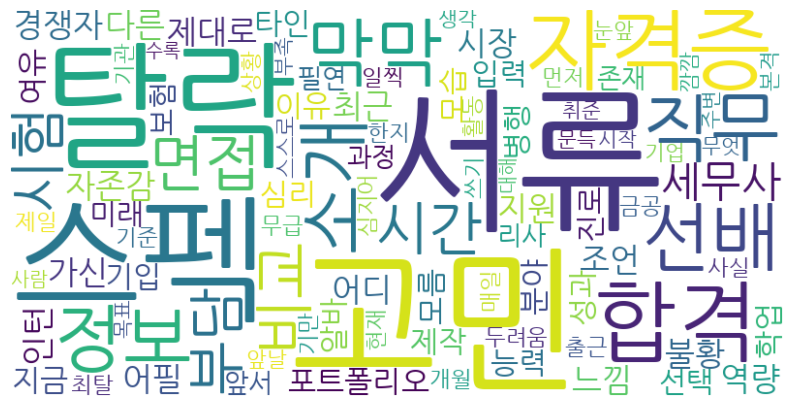

In [ ]:
# '취업'과 '준비' 단어 제거
for word in ['취업', '준비']:
    if word in counter:
        del counter[word]

# 워드클라우드 생성
wordcloud = WordCloud(font_path='NanumGothic.ttf', background_color='white', width=800, height=400)
wordcloud.generate_from_frequencies(dict(counter))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()